In [22]:
import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"

import sys
import time
from pathlib import Path
import cv2
import matplotlib.pyplot as plt
import numpy as np

sys.path.insert(0, str(Path.cwd().parent))
from deepface import DeepFace
from config import DATASET_PATH

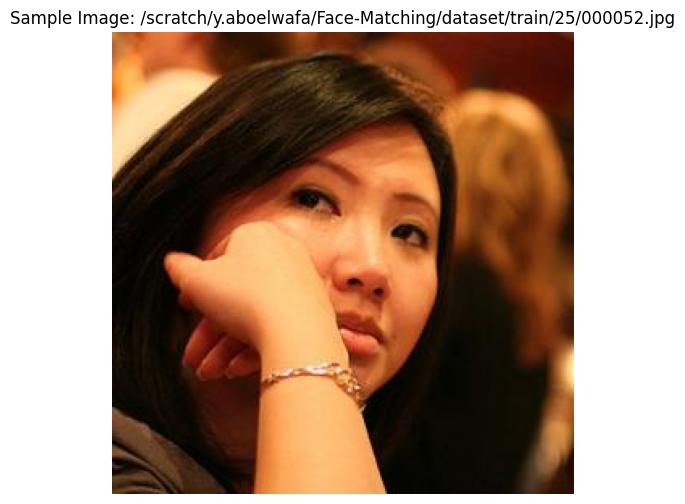

In [18]:
sample_image = Path(DATASET_PATH) / "train" / "25" / "000052.jpg"
img_bgr = cv2.imread(str(sample_image))
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(6, 6))
plt.imshow(img_rgb)
plt.title(f"Sample Image: {sample_image}")
plt.axis("off")
plt.show()

In [19]:
detectors = [
    "opencv",
    "dlib",
    "yunet",
    "centerface",
    "retinaface",
    "mtcnn",
    "yolov8n",
    "yolov11n",
]
results = {}
for det in detectors:
    try:
        start_time = time.time()
        faces = DeepFace.extract_faces(
            img_path=sample_image,
            detector_backend=det,
            enforce_detection=False,
            align=True,
            color_face="rgb",
            normalize_face=False,
        )
        end_time = time.time()
        print(f"[{det}] Time taken: {end_time - start_time:.4f} seconds")
        results[det] = faces
        for i, f in enumerate(faces):
            area = f["facial_area"]
            print(f"{det}: confidence={f['confidence']:.4f}  "
                  f"region=({area['x']}, {area['y']}, {area['w']}, {area['h']})\n")
    except Exception as e:
        print(f"[{det:>12s}] ERROR: {e}")
        results[det] = []

[opencv] Time taken: 0.1174 seconds
opencv: confidence=0.9800  region=(71, 54, 162, 162)

[dlib] Time taken: 0.1939 seconds
dlib: confidence=0.5300  region=(75, 59, 155, 154)

[yunet] Time taken: 0.0344 seconds
yunet: confidence=0.9100  region=(85, 56, 122, 166)

[centerface] Time taken: 0.1844 seconds
centerface: confidence=0.6000  region=(75, 51, 131, 179)

[retinaface] Time taken: 0.3568 seconds
retinaface: confidence=1.0000  region=(56, 47, 148, 189)

[mtcnn] Time taken: 0.2819 seconds
mtcnn: confidence=1.0000  region=(94, 74, 104, 150)

[yolov8n] Time taken: 0.0726 seconds
yolov8n: confidence=0.8100  region=(65, 53, 138, 175)

[yolov11n] Time taken: 0.0824 seconds
yolov11n: confidence=0.8500  region=(66, 54, 137, 176)



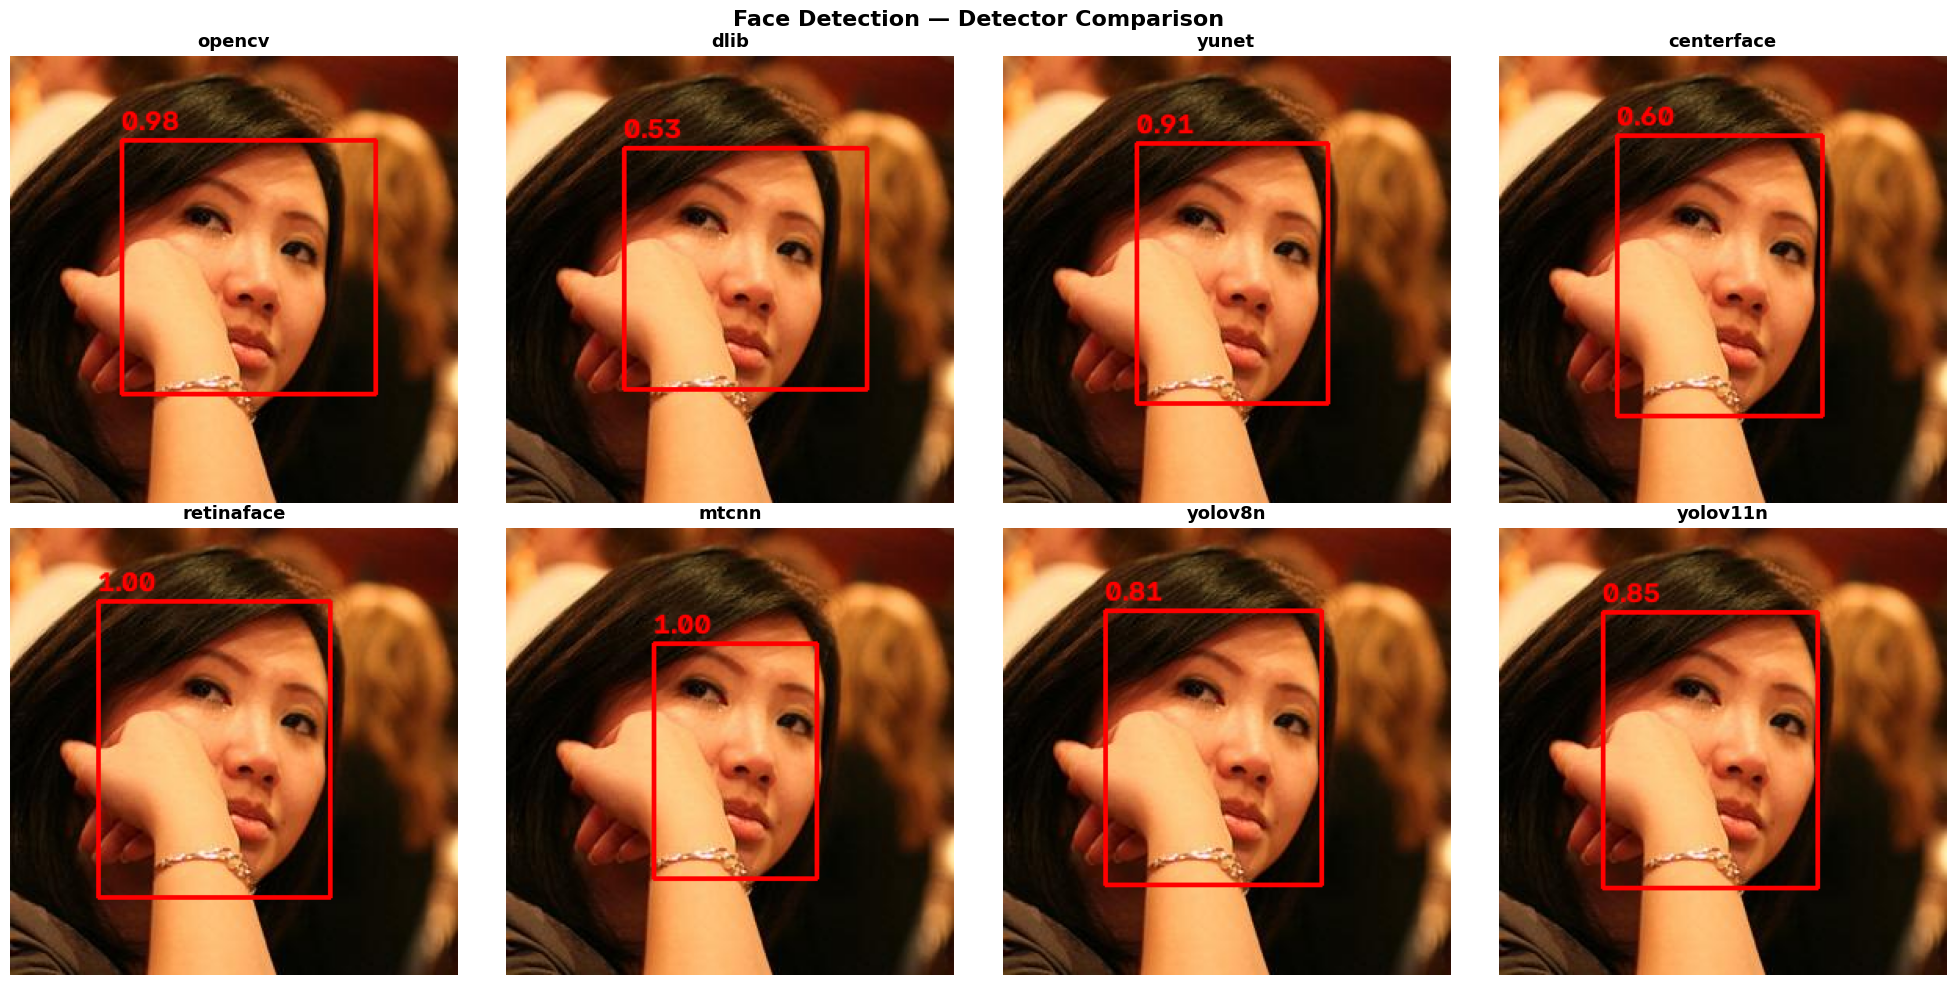

In [20]:
n = len(detectors)
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for idx, det in enumerate(detectors):
    ax = axes[idx]
    annotated = img_rgb.copy()
    faces = results.get(det, [])
    for i, f in enumerate(faces):
        area = f["facial_area"]
        x, y, w, h = area["x"], area["y"], area["w"], area["h"]
        color = (255,0,0)
        cv2.rectangle(annotated, (x, y), (x+w, y+h), color, 2)
        label = f"{f['confidence']:.2f}"
        cv2.putText(annotated, label, (x, y-6),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)
    ax.imshow(annotated)
    face_count = len(faces)
    ax.set_title(f"{det}", fontsize=13, fontweight="bold")
    ax.axis("off")

for idx in range(n, len(axes)):
    axes[idx].axis("off")

plt.suptitle("Face Detection — Detector Comparison", fontsize=16, fontweight="bold", y=0.98)
plt.tight_layout()
plt.show()